# Exercise - Decoupling of Printed Circuit Boards - 1c)

Exercise in the lecture Machine Learning in Electrical Engineering and Information Technology, Decoupling of Printed Circuit Boards

* Lecture Period: Summer 2026 ([StudIP](https://e-learning.tuhh.de/studip/dispatch.php/course/details?sem_id=1be148fc0ce85172e3902adf814a909b&again=yes))
* Institute: Institut für Theoretische Elektrotechnik ([TET](https://www.tet.tuhh.de/en/institute/))
* University: Hamburg University of Technology ([TUHH](https://www.tuhh.de/tuhh/en/startpage))
* Exercise Supervisor: Til Hillebrecht and Jan Heßling


The first part of the exercise is about the resonance of LC-Circuits. c) consists of two series resonance circuits in a parallel configurations *L1*, *L2*, *C1*, *C2*. In the figure below the equivalent circuit is shown on the left and the magnitude of the impedance for one *L1* and *C1* is shown on the right.

|||
|:-:|:-:|
|<img title="equivalent circuit 2 LC Series in Parallel" src='figures/par_ser_l_c.png' width='250'/>|<img title="equivalent circuit LC Parallel" src='figures/imp_par_ser_lc.png' width='450'/>|
|**Equivalent Circuit**|**Impedance of Equivalent Circuit**|

#### Module Import
**Modules** are imported, which have to be available to the python interpreter.  
**helper_functions (hp)** is a module in the working directory providing some functions making the notebook more tidy.

**Module Links for Further Information:**
* [pandas](https://pandas.pydata.org/)
* [numpy](https://numpy.org/)
* [matplotlib](https://matplotlib.org/)
* [pickle](https://docs.python.org/3/library/pickle.html)
* [mlflow](https://mlflow.org/)
* [scikit-learn](https://scikit-learn.org/stable/index.html)

In [1]:
# code cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

import os
os.environ["GIT_PYTHON_REFRESH"] = "quiet"

import mlflow
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import helper.helper_functions as hp # toolbox providing functionality -> resulting in cleaner looking notebook

#### Load Data from Working Directory

From the local directory the CSV file is loaded. The component parameters are ***L1*** and ***C1***, the resonance frequency is ***omega***.  
In the following, ***L1*** and ***C1*** are input features, ***omega*** is the resonance frequency of the resonance circuit.

All data samples are split in **Test** and **Train** data before any operations (scaling, ...) are performed.  

**Variables:**
* *test_size* &rarr; share of data used for testing the trained neural network
* *file_name* &rarr; file containing the data
* *input_features* &rarr; columns of the data file used as input features
* *outptut_features* &rarr; columns of the data file used as output features

In [2]:
# variables
test_size = 0.2
file_name = "data/task_1_c.csv"
input_features = ["L1", "L2", "C1", "C2"]
output_features = ["Omega_1", "Omega_2", "Omega_3"]

In [3]:
# code cell
data_set = pd.read_csv(file_name)
data_set_train, data_set_test = train_test_split(data_set, test_size=test_size, shuffle=True)

# separate input and output data
train_input = data_set_train[input_features]
train_output = data_set_train[output_features]
test_input = data_set_test[input_features]
test_output = data_set_test[output_features]

In [4]:
data_set_train.head()

,L1,L2,C1,C2,Omega_1,Omega_2,Omega_3
16869,6.468126e-07,9.594788e-08,4.587676e-08,1.111116e-09,5805163.0,35228360.0,96850650.0
689819,2.640510e-08,1.470470e-08,4.901420e-08,1.663090e-07,27796820.0,25348590.0,20221530.0
460865,4.036793e-09,2.281427e-07,7.663932e-07,3.176714e-09,17978600.0,36897520.0,37145620.0
858616,6.327149e-09,4.525399e-09,1.424106e-07,1.808704e-08,33313850.0,75772850.0,110532000.0
328544,2.249812e-07,1.997876e-09,1.310390e-09,8.741782e-08,58240700.0,58416780.0,75668610.0


#### Data Visualization

Visualizing the distribution of the input and output data is important for better understanding the obtained results. Input parameters are shown on the left, output value is shown on the right side of the figure split in train and test data.

**Variables:**
* *nr_slots* &rarr; how many slots are used for sorting the data samples

In [5]:
# variables
nr_slots = 10

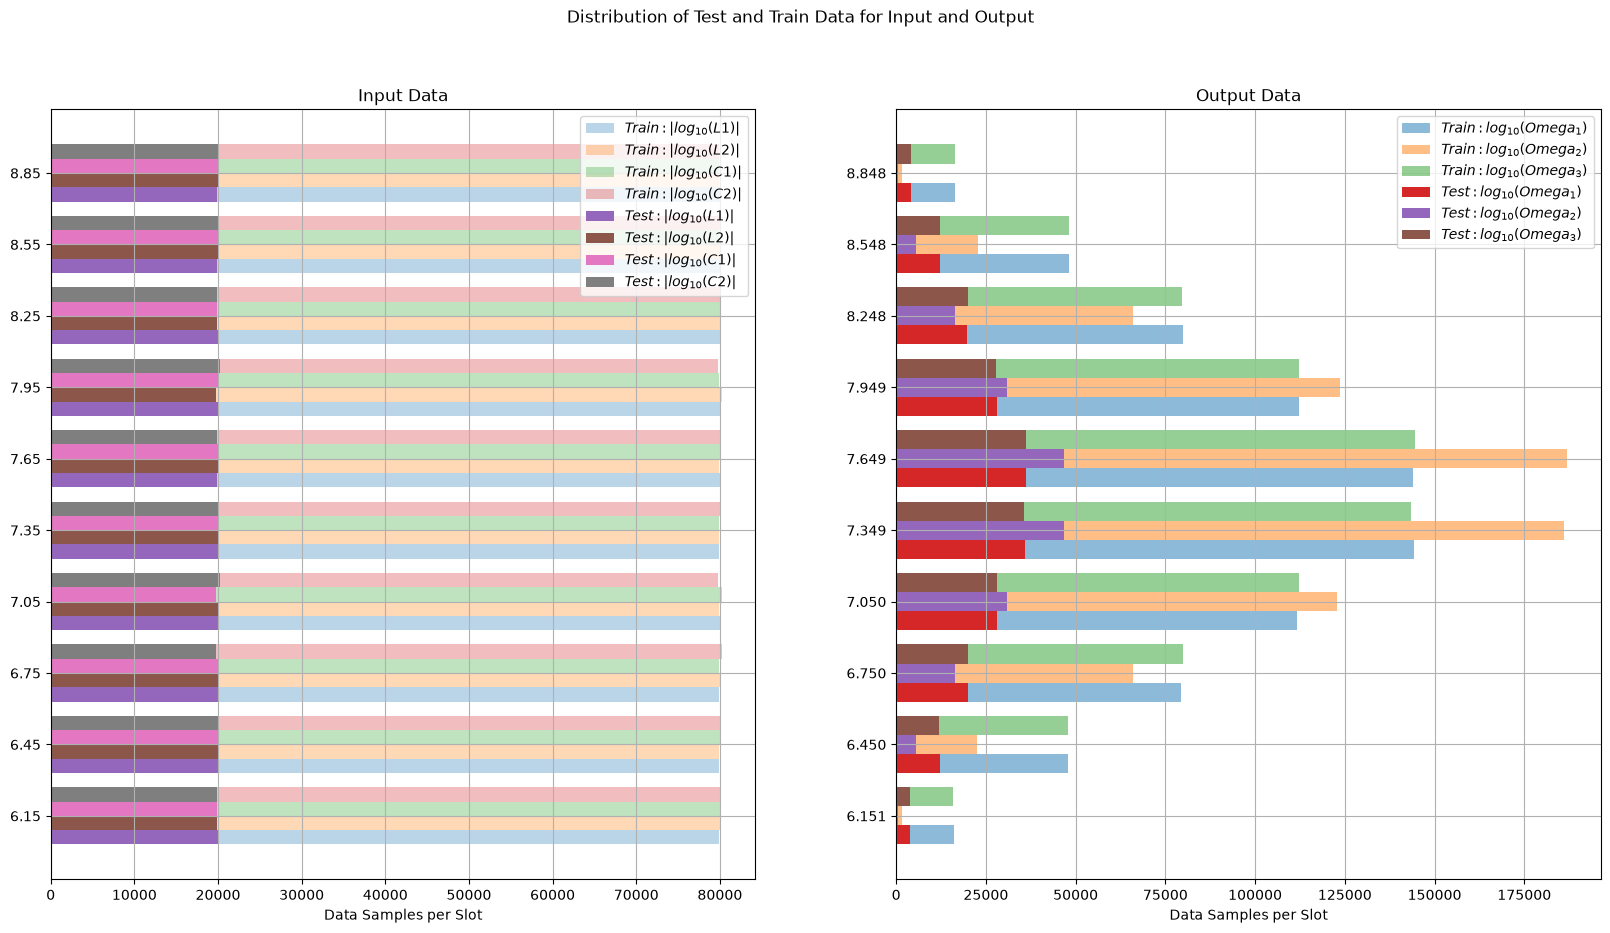

In [6]:
### code cell
fig, axs = plt.subplots(1, 2, figsize=(20,10), sharey=False)

_ , bins_input, _ = axs[0].hist(abs(np.log10(train_input)), nr_slots, label=[f"$Train: |log_{{{10}}}({x})|$" for x in input_features], alpha=0.3, orientation='horizontal')
axs[0].hist(abs(np.log10(test_input)), bins_input, label=[f"$Test: |log_{{{10}}}({x})|$" for x in input_features], alpha=1, orientation='horizontal')

_, bins_output, _ = axs[1].hist(np.log10(train_output), nr_slots, label=[f"$Train: log_{{{10}}}({x}$)" for x in output_features],alpha=0.5, orientation='horizontal')
axs[1].hist(np.log10(test_output), bins_output, label=[f"$Test: log_{{{10}}}({x}$)" for x in output_features],alpha=1, orientation='horizontal')

bin_output = [bins_output[x]/2+bins_output[x+1]/2 for x in range(len(bins_output)-1)]
bin_input = [bins_input[x]/2+bins_input[x+1]/2 for x in range(len(bins_input)-1)]
axs[1].set_yticks(bin_output)
axs[0].set_yticks(bin_input)
axs[0].set_xlabel("Data Samples per Slot")
axs[1].set_xlabel("Data Samples per Slot")
axs[1].set_title("Output Data")
axs[0].set_title("Input Data")

axs[0].legend()
axs[1].legend()
axs[0].grid()
axs[1].grid()

_ = fig.suptitle("Distribution of Test and Train Data for Input and Output")

#### Start of your own Code

Start your own code below this cell. Train different neural networks, predicting only one frequency e.g. *omega_1*, or multiple frequencies e.g. *omega_1* and *omega_2*.  
Remember the individual steps you have to perform, e.g. data scaling.


In [7]:
# variables
scaling_input = True
scaling_output = True
scaler_name ='scaler'
out_scaler = 1e6

In [8]:
# code cell
scaler = StandardScaler()
scaler = scaler.fit(train_input)

# store artifact in local directory
pickle.dump(scaler, open(f"{scaler_name}.pkl", "wb"))

if scaling_input:
    train_input_scaled = scaler.transform(train_input)
    test_input_scaled = scaler.transform(test_input)
else:
    train_input_scaled = train_input.to_numpy()
    test_input_scaled = test_input.to_numpy()

# transform output frames to numpy array and scale to MHz
if scaling_output:
    train_output_scaled = train_output.to_numpy()/out_scaler
    test_output_scaled = test_output.to_numpy()/out_scaler
else:
    train_output_scaled = train_output.to_numpy()
    test_output_scaled = test_output.to_numpy()

train_output_scaled = np.reshape(train_output_scaled, (len(train_output_scaled),3))
test_output_scaled = np.reshape(test_output_scaled, (len(test_output_scaled),3))

#### Tracking Experiments

Tracking experiments is an important step investigating the performance of machine learning tools in general. Due to its simplicity mlflow is a useful tool, providing local and server features. Here, local features are used only.  
In the working directory a folder *mlruns* is created. Different experiments can be stored inside this folder defined by the *experiment_id*. Within each experiment runs of training e.g. neural networks are stored.  
For each run, defined by the *run_id*, parameters (layer of the neural network, ...), metrics (mean squared error, ...), and artifacts (trained neural network, scaler, ...) are stored.

**Variables:**
* *experiment_name* &rarr; name of the experiment

In [9]:
# generate mlflow environment/experiment for tracking
experiment_name = "Task I : c"
experiment_id = hp.get_experiment_id(experiment_name)

#### Training Neural Networks

**Sklearn** provides methods to train different kind of machine learning tools e.g. neural networks. To predict the resonance of the LC circuit we have to define a regressor. Besides standard parameters defined by sklearn, we define parameters which are varied for investigation.
All parameters can be defined in lists. All possible combinations of the lists are investigated e.g. **3** topologies, **2** initial learning rates &rarr; in **6** neural network trainings.  
All possible combinations of the parameters are designed using the helper function *get_product_dict(_)*. For each of the parameter set one mlflow run is started inside the specified experiment_id.

**Variables:**
* *hidden_layer_sizes* &rarr; topologies of neural networks
* *solver* &rarr; solver used during training the neural network and optimizing the weights
* *learning_rate_init* &rarr; initial learning rates used for the solver
* *learning_rate* &rarr; learning rates
* *max_iter* &rarr; maximum number of iterations before termination of the training

Possible parameters can be identified on https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html


In [10]:
# variables
param_grid = {'hidden_layer_sizes' : [(100,100)],
              'learning_rate_init' : [1e-3],
              'learning_rate' : ['constant'],
              'solver' : ['adam'],
              'max_iter' : [500]
              }

### **Exercise - Tasks**

1. Identify a neural network topology providing a good solution to the prediction of the anti resonance of the parallel LC circuit.
2. How is the impact of the initial learning rate?
3. How is the difference by choosing a *constant*, *adaptive*, or *invscaling* learning rate? What does it mean?

In [11]:
# code cell
for para_set in list(hp.get_product_dict(**param_grid)):
    print(para_set)
    nn_regressor = MLPRegressor(**para_set)
    with mlflow.start_run(experiment_id=experiment_id):
        fit = nn_regressor.fit(train_input_scaled, train_output_scaled)
        y_predicted = nn_regressor.predict(test_input_scaled)
        hp.set_mlflow_metrics(nn_regressor, y_predicted, test_output_scaled)
        mlflow.log_artifact(f"{scaler_name}.pkl", f'{scaler_name}')

{'hidden_layer_sizes': (100, 100), 'learning_rate_init': 0.001, 'learning_rate': 'constant', 'solver': 'adam', 'max_iter': 500}


#### Evaluating Neural Network Training

After training the different neural networks, they have to be evaluated. First the evaluation metric has to be defined (mean squared error, mean absolute error, ...). From the mlflow experiment all runs are evaluated based on the defined metric. Listed in the table the run_id can be used to select the best performing neural network. For a better overview columns are partially renamed.

**Variables:**
* *evaluation_metric* &rarr; metric for sorting the runs of the experiment

### **Exercise - Task**

1. Evaluated your neural network and compare with results achieved in **Task 1 a)**.
1. Can you identify similarities of the neural networks, and their performance in **a)** and **b)**?


In [12]:
# variables
evaluation_metric = "metrics.mean_squared_error_test_input_scaled"

In [13]:
# code cell
runs = mlflow.search_runs(experiment_id)
runs = runs.sort_values(by=evaluation_metric)
runs = runs [['run_id', 'tags.mlflow.runName', 'params.hidden_layer_sizes', 'metrics.iterations','metrics.training_mean_squared_error','metrics.mean_squared_error_test_input_scaled']]
runs.rename(columns={'tags.mlflow.runName' : 'Run Name', 'params.hidden_layer_sizes' : 'Hidden Layer', 'metrics.iterations' : 'Iterations', 'metrics.training_mean_squared_error' : 'Training MSE', 'metrics.mean_squared_error_test_input_scaled' : 'Testing MSE'})

,run_id,Run Name,Hidden Layer,Iterations,Training MSE,Testing MSE
1,558cf7f60f8e4b5eb4404e36a469d24e,sassy-dog-125,"(100, 100)",34.0,21.227653,21.091181
0,1beb090946a04a7b8134fa74bcc85a7f,luminous-bug-861,"(100, 100)",63.0,42.245848,43.203178


# Reevaluate the Best Neural Network

Using the run_id you can evaluate the neural network of the run again. Copy the run_id from the previous cell output to the next cell and load the neural network. The scaler is loaded but not applied, because the same data as in the beginning is used. 

**Variables:**
* *run_id* &rarr; id of the run for further evaluation

### Exercise - Task

1. Can we use a neural network from **Task 1 a)** to predict the anti resonance of the parallel circuit?  
1. What is your expectation? 
1. How does the neural network perform in comparison?

In [14]:
# Load the best run from the current experiment. A hard-coded run ID can
# point to a model trained with a different set of input features.
run_id = runs.iloc[0]["run_id"]
loaded_ann = mlflow.sklearn.load_model(f'runs:/{run_id:s}/model')
loaded_scaler = hp.get_scaler(run_id)

expected_features = list(loaded_scaler.feature_names_in_)
if expected_features != list(test_input.columns):
    raise ValueError(
        f"Run {run_id} expects {expected_features}, but test data has "
        f"{list(test_input.columns)}. Select a run trained for this task."
    )

#### Visualize Reevaluation
Using the loaded neural network from the mlflow experiment and the test data predictions are performed. The result of the predictions is shown in the figure below. For perfect predictions all samples have to be on the red line.  

The figure is shown using two different scales logarithmic and linear providing two different interpretation of the results. 

In [ ]:
# Visualize the Available Data Samples, split for test and train data
y_predicted = loaded_ann.predict(loaded_scaler.transform(test_input))
fig, axs = plt.subplots(1, 2, figsize=(16,8))
for ii in range(2):
    if scaling_output:
        axs[ii].scatter(test_output/out_scaler, y_predicted, label='Data Points', marker='X')
    else:
        axs[ii].scatter(test_output, y_predicted, label='Data Points', marker='X')
    if ii == 0:
        axs[ii].set_xscale('log')
        axs[ii].set_yscale('log')
        axs[ii].set_title('Logarithmic Scaled Axis')
    elif ii == 1:
        axs[ii].set_title('Linear Scaled Axis')
    axs[ii].set_xlabel("Resonance Frequency Expectation (MHz)")
    axs[ii].set_ylabel("Resonance Freqeuncy Prediction (MHz)")
    min = axs[ii].get_xlim()[0] if axs[ii].get_xlim()[0] < axs[ii].get_ylim()[0] else axs[ii].get_ylim()[0]
    max = axs[ii].get_xlim()[-1] if axs[ii].get_xlim()[-1] > axs[ii].get_ylim()[-1] else axs[ii].get_ylim()[-1]
    axs[ii].set_xlim(min, max)
    axs[ii].set_ylim(min, max)
    axs[ii].plot([min, max], [min,max], label='Perfect Prediction', c='r', lw=3)
    axs[ii].legend()
# ax.set

fig.suptitle("Prediction and Expectation")